# ALONE TV SHOW
## Why we chose this project?
Alone is s survival TV series where 10 survivalists are dropped in an extremely remote area (Arctic winter) and must fend for themselves. Its impressive to see how the winning contestants use their skills, endurance, and mental fortitude to last 100 days in such a harsh living condition.

## Data Description
It uses a collection of datasets about the TV series:

1. `survivalists.csv`
A data frame of survivalists across all 9 seasons detailing name and demographics, location and profession, result, days lasted, reasons for tapping out (detailed and categorised), page URL.

| Feature Name   | Description |
| -------- | ------- |
| `season`  | The season number   |
| `name` | Name of the survivalist     |
| `version` | The version country code (currently only US but being preppred or other versions)|
| `id` | Survivalist unique ID |
| `age` | Age of survivalist |
| `gender` | Gender |
| `city` |  City |
| `state` | State |
| `country` | Country |
|`result`| Place the survivalist finished in the season|
| `days_lasted` | The number of days lasted in the game before tapping out or winning|
| `medically_evacuated` | Logical. If the survivalist was medically evacuated from the game |
| `reason_tapped_out` | The reason the survivalist tapped out of the game. NA means they were the winner |
| `reason_category` | A simplified category of the reason for tapping out |
| `team` | The team they were associated with (only for season 4)|
| `day_linked_up` | Day the team members linked up |
| `profession` | Profession of the survivalist |
---

2. `episodes.csv`
This dataset contains details of each episode including the title, number of viewers, beginning quote and IMDb rating.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `episode_number_overall` | Episode number across seasons |
| `episode` | Episode number |
| `title` | Episode title |
| `air_date` | Date the episode originally aired |
| `viewers` | Number of viewers in the US (millions) |
| `quote` | The beginning quote |
| `author` | Author of the beginning quote |
|`imdb_rating` | IMDb rating of the episode |
| `n_ratings` | Number of ratings given for the episode |
----

3. `seasons.csv`
The season summary dataset includes location, latitude and longitude, and other season level information. It includes the date of drop off where the information exists.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `location` | Location |
| `country` | Country |
| `n_survivors` | Number of survivalists in the season. In season 4 there were 7 teams of 2 |
| `lat` | Latitude |
| `lon` | Longitude |
| `date_drop_off` | The date the survivalists were dropped off |
---

4. `loadouts.csv`
Each survivalist is allowed to take with them 10 items. This dataset includes information on each survivalist’s loadout.

| Feature Name   | Description |
| -------- | ------- |
| `version` | Country code for the version of the show |
| `season` | The season number |
| `id` | Survivalist unique ID |
| `name` | Name of the survivalist |
| `item_number` | Item number |
| `item_detailed` | Detailed loadout item description |
| `item` | Loadout item. Simplified for aggregation |

## **Installing Neccessary Libraries**

In [493]:
!pip install psynlig -q

In [494]:
!pip install umap-learn -q

In [495]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Merging Datasets**

In [496]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [497]:
epi = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/episodes.csv')
ses = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/seasons.csv')
sur = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/survivalists.csv')
load = pd.read_csv('/content/drive/MyDrive/Spring2026/UnsupervisedML/BA820TeamProject/loadouts.csv')

In [498]:
# -----------------------------
# 1. Normalize version column
# -----------------------------

for _df in [epi, ses, sur, load]:
    if 'version' not in _df.columns:
        _df['version'] = 'US'

if 'id' not in sur.columns:
    sur = sur.copy()
    sur['id'] = sur['name']  # fallback to name as unique identifier

if 'id' not in load.columns:
    load = load.copy()
    load['id'] = load['name']  # fallback for loadouts


# -------------------------------------------------
# 2. CONTESTANT DATA
# -------------------------------------------------

df = (
    sur.merge(
        ses[['version','season','location','lat','lon','date_drop_off']],
        on=['version','season'],
        how='left'
    )
    .groupby(['version','season','id','name'], as_index=False)
    .agg({
        'age': 'first',
        'gender': 'first',
        'profession': 'first',
        'city': 'first',
        'state': 'first',
        'country': 'first',
        'days_lasted': 'max',
        'result': 'first',
        'medically_evacuated': 'first',
        'reason_category': 'first',
        'location': 'first',
        'lat': 'first',
        'lon': 'first',
        'date_drop_off': 'first',
        'team':'first'
    })
)

# Hard guarantee: no duplicate people
assert df[['version','season','id']].duplicated().sum() == 0


# -------------------------------------------------
# 3. EPISODE DATA
# -------------------------------------------------

epi_season = (
    epi.groupby(['version','season'], as_index=False)
       .agg({
           'viewers': 'mean',
           'imdb_rating': 'mean',
           'n_ratings': 'mean'
       })
)

df = df.merge(
    epi_season,
    on=['version','season'],
    how='left'
)


# -------------------------------------------------
# 4. LOADOUT DATA
# -------------------------------------------------

load_person = (
    load[['version','season','id','item','item_detailed']]
    .drop_duplicates()
    .groupby(['version','season','id'], as_index=False)
    .agg({'item': list, 'item_detailed' : list})
)


df = df.merge(
    load_person,
    on=['version','season','id'],
    how='left'
)

df

,version,season,id,name,age,gender,profession,city,state,country,...,location,lat,lon,date_drop_off,team,viewers,imdb_rating,n_ratings,item,item_detailed
0,US,1,Alan Kay,Alan Kay,40,Male,Corrections Officer,Blairsville,Georgia,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Pot, Ferro rod, Cante...","[Saw, Axe, Sleeping bag, Large 2-quart pot, Fe..."
1,US,1,Brant McGee,Brant McGee,44,Male,US Army Guard and Former US Coast Guard,Albemarle,North Carolina,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12×12 ground sheet tarp, 550 paracord – 20m, ..."
2,US,1,Chris Weatherman,Chris Weatherman,41,Male,Author,Umatilla,Florida,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Saw, Axe, Sleeping bag, Ferro rod, Pot, Cante...","[Saw, Axe, Sleeping bag, Ferro rod, Large 2 qu..."
3,US,1,Dustin Feher,Dustin Feher,37,Male,Carpenter,Pittsburgh,Pennsylvania,United States,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Paracord, Axe, Sleeping bag, Pot, Ferro rod, ...","[550 paracord – 20m, Axe, Sleeping bag, Large ..."
4,US,1,Joe Robinet,Joe Robinet,24,Male,Carpenter,Windsor,Ontario,Canada,...,Quatsino,50.72444,-127.498056,None,None,1.9697,7.672727,101.545455,"[Tarp, Paracord, Axe, Sleeping bag, Pot, Ferro...","[12x 12 tarp, 550 paracord – 20m, Axe, Sleepin..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,US,9,Juan Pablo Quinonez,Juan Pablo Quinonez,30,Male,Outdoor Professional,Pinawa,Manitoba,Canada,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Ferro rod, Paracord, Pot, Axe, Fishing gear, ...","[Ferro rod, Paracord, 2-quart pot, Axe, Fishin..."
90,US,9,Karie Lee Knoke,Karie Lee Knoke,57,Female,Wilderness/Primitive Skills Instructor,Sandpoint,Idaho,United States,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Paracord, Sleeping bag, Pot, Ferro rod, Fishi...","[Paracord, Sleeping bag, 2-quart pot, Ferro ro..."
91,US,9,Teimojin Tan,Teimojin Tan,31,Male,Physician,Montreal,Quebec,Canada,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Sleeping bag, Axe, Multitool, Ferro rod, Pot,...","[Sleeping bag, Axe, Multitool, Ferro rod, 2-qu..."
92,US,9,Terry Burns,Terry Burns,30,Male,Commercial Fisherman,Homer,Alaska,United States,...,Nunatsiavut,59.66000,-64.273611,2021-09-18,None,NaN,7.933333,27.666667,"[Axe, Sleeping bag, Bow and arrows, Fishing ge...","[Axe, Sleeping bag, Bow and arrows, Fishing li..."


# **1. Domain Question**




## **M2 (Old Question)**

**How do season-level survival patterns differ between Season 1 and other seasons, and do these differences align with changes in viewership and ratings in a way that could explain audience decline over time?**

This earlier question focused on Season 1 as a reference point and examined whether changes in survival patterns contributed to viewer loss.

## **M4 (New Question)**

**Can we group the seasons of Alone into distinct types based on survival outcomes, contestant characteristics, geography, and audience engagement? If so, what defines each group?**

Rather than comparing seasons on a few individual metrics (such as just survival pattern and viewership), we now analyze all seasons together across multiple metrics simultaneously.

Importantly, we are no longer comparing the rest seasons to Season 1. Instead, we treat each season equally and allow the data to reveal natural clusters based on overall similarity.

This multidimensional approach allows us to build a complete structural profile for each season and identify meaningful groupings.

# **2. Data Preprocessing**

In [499]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   version              94 non-null     object 
 1   season               94 non-null     int64  
 2   id                   94 non-null     object 
 3   name                 94 non-null     object 
 4   age                  94 non-null     int64  
 5   gender               94 non-null     object 
 6   profession           94 non-null     object 
 7   city                 94 non-null     object 
 8   state                93 non-null     object 
 9   country              94 non-null     object 
 10  days_lasted          94 non-null     int64  
 11  result               94 non-null     int64  
 12  medically_evacuated  94 non-null     bool   
 13  reason_category      84 non-null     object 
 14  location             94 non-null     object 
 15  lat                  94 non-null     float

## **1. Dropping Irrelevant Columns**

In [500]:
df_clean = df.drop(columns=[
    "version",
    "id",
    "date_drop_off",
    "team",
    "item_detailed",
]).copy()

## **2. Handling Missing Values**

In [501]:
missing_count = df_clean.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df_clean)).round(3)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct})

missing_report

,missing_count,missing_pct
viewers,10,0.106
reason_category,10,0.106
state,1,0.011
age,0,0.000
name,0,0.000
season,0,0.000
gender,0,0.000
country,0,0.000
days_lasted,0,0.000
profession,0,0.000


In [502]:
df_clean["reason_category"] = df_clean["reason_category"].fillna("Unknown")
df_clean["state"] = df_clean["state"].fillna("Unknown")

In [503]:
df_clean["viewers"] = df_clean["viewers"].fillna(df_clean.groupby("season")["viewers"].transform("median"))
df_clean["viewers"] = df_clean["viewers"].fillna(df_clean["viewers"].median())

## **3. Defining Numeric Variables and Handling Skewness**

In [504]:
numeric_variables = [
    "age",
    "days_lasted",
    "lat",
    "lon",
    "viewers",
    "imdb_rating",
    "n_ratings"]

In [505]:
df_clean[numeric_variables].skew().sort_values(ascending=False)

,0
lon,2.113712
viewers,0.684702
n_ratings,0.583941
days_lasted,0.176316
age,0.019834
imdb_rating,-0.108219
lat,-2.470944


In [506]:
df_clean["log_viewers"] = np.log1p(df_clean["viewers"])
df_clean["log_n_ratings"] = np.log1p(df_clean["n_ratings"])

df_clean = df_clean.drop(columns=["viewers", "n_ratings"])

## **4. Defining Categorical Variables and Changing Dtype**

In [507]:
df_clean["item"] = df_clean["item"].apply(tuple)

In [508]:
categorical_variables = [
    "season",
    "gender",
    "profession",
    "city",
    "state",
    "country",
    "reason_category",
    "location",
    "item"]

for col in categorical_variables:
    df_clean[col] = df_clean[col].astype("category")

## **5. Sanity Check**

In [509]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   season               94 non-null     category
 1   name                 94 non-null     object  
 2   age                  94 non-null     int64   
 3   gender               94 non-null     category
 4   profession           94 non-null     category
 5   city                 94 non-null     category
 6   state                94 non-null     category
 7   country              94 non-null     category
 8   days_lasted          94 non-null     int64   
 9   result               94 non-null     int64   
 10  medically_evacuated  94 non-null     bool    
 11  reason_category      94 non-null     category
 12  location             94 non-null     category
 13  lat                  94 non-null     float64 
 14  lon                  94 non-null     float64 
 15  imdb_rating          94 n

## **6. Special Variables**

In [510]:
df_clean["medically_evacuated"] = df_clean["medically_evacuated"].astype(int)

**REASON**

The boolean medically_evacuated variable is converted to a 0/1 format so that, when aggregated at the season level, its mean represents the percentage of contestants medically evacuated in each season. This serves as an important indicator of the relative harshness or medical risk associated with a season.

Treating it as a categorical variable would prevent meaningful aggregation and would exclude an important indicator of season difficulty from the analysis.

In [511]:
df_clean["abs_latitude"] = df_clean["lat"].abs()

**REASON**

Latitude was converted to its absolute value to measure how far a location is from the equator. Locations farther from the equator are generally colder and more extreme, so this helps capture how tough the environment may be. The sign of latitude only indicates direction (north vs south), which is not relevant for our analysis.

Longitude was not converted because east-west position does not consistently reflect climate severity. Unlike latitude, longitude does not systematically determine temperature or climatic severity. Therefore, longitude was not included in our season-level analysis.

# **3. Season-level Aggregation and Dataframe**

In [512]:
season_df = (
    df_clean.groupby("season", as_index=False)
    .agg(
        # Survival Metrics
        mean_days_lasted=("days_lasted", "mean"),
        std_days_lasted=("days_lasted", "std"),
        max_days_lasted=("days_lasted", "max"),
        medical_evac_rate=("medically_evacuated", "mean"),

        # Demographics
        mean_age=("age", "mean"),
        std_age=("age", "std"),

        # Audience Engagement
        avg_log_viewers=("log_viewers", "mean"),
        avg_imdb_rating=("imdb_rating", "mean"),
        avg_log_n_ratings=("log_n_ratings", "mean"),

        # Geography
        abs_latitude=("abs_latitude", "first"),

        # Contestants
        n_contestants=("name", "count")))

season_df

/tmp/ipython-input-1248453823.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,season,mean_days_lasted,std_days_lasted,max_days_lasted,medical_evac_rate,mean_age,std_age,avg_log_viewers,avg_imdb_rating,avg_log_n_ratings,abs_latitude,n_contestants
0,1,21.600000,23.566455,56,0.000000,35.100000,8.047774,1.088461,7.672727,4.630306,50.724440,10
1,2,34.400000,24.954180,66,0.100000,41.900000,7.922542,0.962822,7.592308,4.216108,50.724440,10
2,3,54.300000,30.861879,87,0.300000,36.700000,9.661493,1.000779,7.820000,4.130355,41.000000,10
3,4,31.428571,32.376901,75,0.285714,35.714286,12.060288,0.921159,7.300000,3.889777,50.724440,14
4,5,30.100000,19.416202,60,0.300000,37.000000,9.877022,0.883933,8.000000,3.958907,49.750000,10
5,6,45.400000,28.016662,77,0.500000,40.200000,6.511528,0.799553,8.018182,4.092828,61.500278,10
6,7,49.900000,31.596237,100,0.300000,36.700000,6.412661,0.835869,8.336364,4.316275,61.500278,10
7,8,41.200000,26.557276,74,0.300000,41.400000,5.660781,0.900872,7.781818,4.072904,51.266667,10
8,9,46.100000,21.635619,78,0.300000,37.600000,10.330107,0.921159,7.933333,3.355735,59.660000,10


# **4. Feature Preparation for Multivariate Analysis**

## **1. Feature Selection**

In [513]:
model_features = [
    "mean_days_lasted",
    "std_days_lasted",
    "max_days_lasted",
    "medical_evac_rate",
    "mean_age",
    "std_age",
    "avg_log_viewers",
    "avg_imdb_rating",
    "avg_log_n_ratings",
    "abs_latitude"]

X = season_df[model_features]

## **2. Standard Scaling and Transformation**

In [514]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **5. Principal Component Analysis (PCA)**

## **1. Fitting PCA**

In [515]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

## **2. Loadings Table and Correlation Heatmap**

In [516]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=model_features,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)])

loadings.round(3)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
mean_days_lasted,-0.406,0.205,0.155,0.129,0.490,-0.143,0.219,0.369,-0.378
std_days_lasted,-0.182,0.331,0.533,0.216,-0.425,-0.059,0.021,-0.015,-0.359
max_days_lasted,-0.395,0.269,0.315,-0.074,0.099,-0.298,-0.295,-0.252,0.634
medical_evac_rate,-0.409,0.163,-0.203,0.138,-0.123,0.563,0.508,0.082,0.368
mean_age,-0.150,-0.408,-0.126,0.711,0.103,-0.185,-0.240,0.282,0.177
std_age,0.203,0.589,-0.292,-0.091,-0.057,0.015,-0.359,0.598,0.121
avg_log_viewers,0.423,0.073,0.225,-0.045,0.363,-0.314,0.543,0.125,0.288
avg_imdb_rating,-0.346,-0.237,0.027,-0.508,0.389,0.197,-0.233,0.095,-0.117
avg_log_n_ratings,0.153,-0.339,0.594,-0.122,-0.174,0.324,-0.077,0.490,0.216
abs_latitude,-0.304,-0.243,-0.214,-0.351,-0.476,-0.542,0.256,0.304,0.036


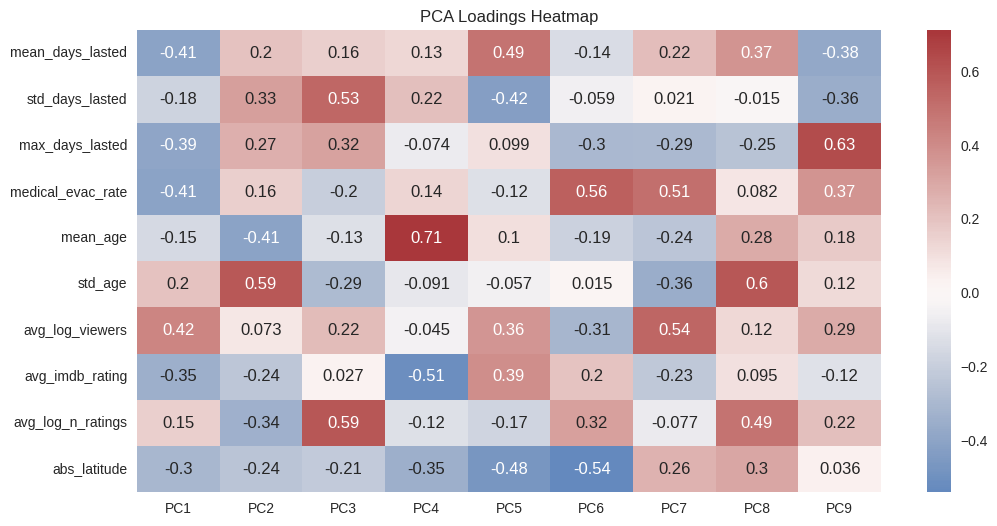

In [517]:
plt.figure(figsize=(12,6))

sns.heatmap(
    loadings,
    annot=True,
    cmap="vlag",
    center=0)

plt.title("PCA Loadings Heatmap")
plt.show()

## **3. Scree Plot - Cumulative Explained Variance**

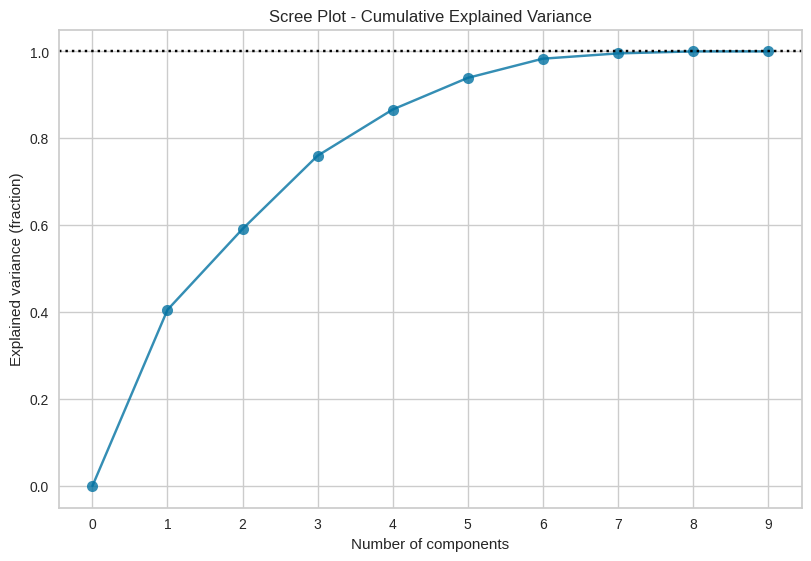

In [518]:
from psynlig import (
    pca_explained_variance,
    pca_explained_variance_bar,)

_, ax = pca_explained_variance(
    pca,
    marker='o',
    markersize=8,
    alpha=0.8)

ax.set_title("Scree Plot - Cumulative Explained Variance")
plt.show()

## **4. Bar Graph - Explained Variance per Principal Component**

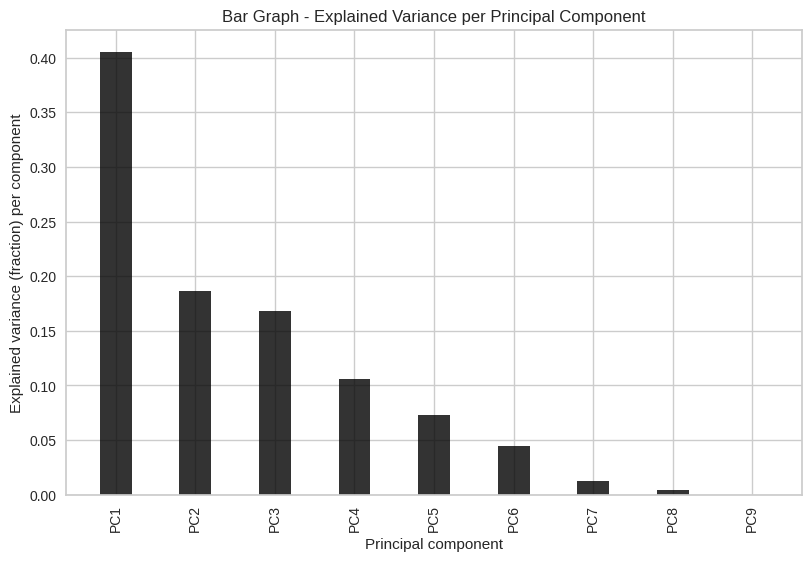

In [519]:
pca_explained_variance_bar(
    pca,
    width=0.4,
    alpha=0.8,
    color='black')

plt.title("Bar Graph - Explained Variance per Principal Component")
plt.show()

## **5. PCA Dimentionality Reduction**

In [520]:
from sklearn.decomposition import PCA

pca_reduced = PCA(n_components=3)
X_reduced = pca_reduced.fit_transform(X_scaled)

print("Cumulative variance explained (3 PCs):")
print(round(np.sum(pca_reduced.explained_variance_ratio_), 3))

Cumulative variance explained (3 PCs):
0.76


## **6. Observation and Interpretation**
PCA and Dimentionsality Reduction

•	The bar graph shows the explained variance for each principal component. PC1 explains about 40% of the total variance, PC2 about 18%, and PC3 about 17%. Together, the first three components explain 76% of the total variance.

•	This indicates that most structural differences between seasons can be captured using just three dimensions instead of using all PCs. The scree plot also shows a clear elbow after PC3, suggesting that additional components contribute limited new information.

•	Therefore, reducing the data to three principal components preserves most of the meaningful variation.

# **6. KMeans Clustering - after PCA**

## **1. Silhoutte Score and Plot**

In [521]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results_pca = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_reduced)
    sil = silhouette_score(X_reduced, labels)
    results_pca.append({"k": k, "silhouette_score": sil})

pd.DataFrame(results_pca)

,k,silhouette_score
0,2,0.206782
1,3,0.260731
2,4,0.332192
3,5,0.257033
4,6,0.153943
5,7,0.071651


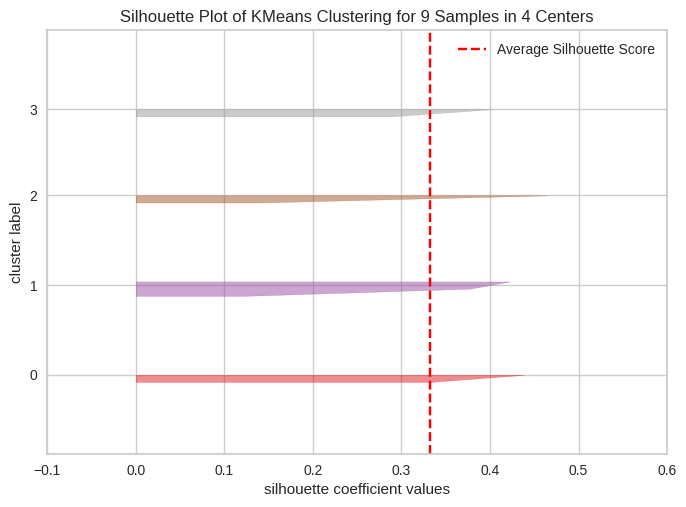

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 9 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [522]:
from yellowbrick.cluster import SilhouetteVisualizer

best_k = 4

model = KMeans(n_clusters=best_k, random_state=42, n_init=10)

visualizer = SilhouetteVisualizer(model)

visualizer.fit(X_reduced)
visualizer.show()

## **2. Cluster Summary**

In [523]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
season_df["cluster"] = kmeans_final.fit_predict(X_reduced)

In [524]:
cluster_summary = (
    season_df
    .groupby("cluster")
    .agg(count=("season", "count"), seasons=("season", lambda x: sorted(list(x))))
    .reset_index())

cluster_summary

,cluster,count,seasons
0,0,2,"[3, 4]"
1,1,3,"[6, 7, 8]"
2,2,2,"[1, 2]"
3,3,2,"[5, 9]"


## **3. Cluster Visualisation on 3D Space**

In [525]:
import plotly.express as px

plot_df = pd.DataFrame(X_reduced, columns=["PC1", "PC2", "PC3"])

plot_df["season"] = season_df["season"].astype(str)
plot_df["cluster"] = season_df["cluster"].astype(str)

fig = px.scatter_3d(
    plot_df,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cluster",
    text="season",
    title="KMeans Clusters on PCA Space")

fig.show()

## **4. Cluster Profile and Cluster Comparison Across Features**

In [526]:
cluster_profile = (season_df.groupby("cluster")[model_features].mean().round(2))

cluster_profile

,mean_days_lasted,std_days_lasted,max_days_lasted,medical_evac_rate,mean_age,std_age,avg_log_viewers,avg_imdb_rating,avg_log_n_ratings,abs_latitude
cluster,,,,,,,,,,
0,42.86,31.62,81.00,0.29,36.21,10.86,0.96,7.56,4.01,45.86
1,45.50,28.72,83.67,0.37,39.43,6.19,0.85,8.05,4.16,58.09
2,28.00,24.26,61.00,0.05,38.50,7.99,1.03,7.63,4.42,50.72
3,38.10,20.53,69.00,0.30,37.30,10.10,0.90,7.97,3.66,54.70


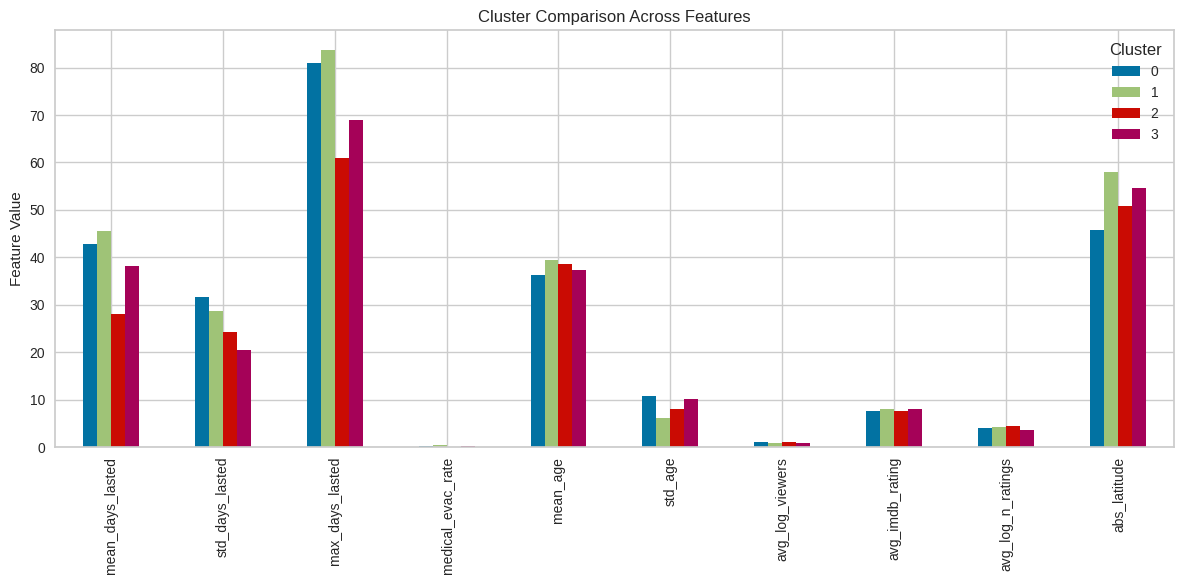

In [527]:
cluster_profile.T.plot(kind="bar", figsize=(12,6))

plt.title("Cluster Comparison Across Features")
plt.ylabel("Feature Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## **5. Observation and Interpretation**
KMeans Clustering - after PCA

### **Silhoutte Score and Silhouette Plot**

•	The silhouette analysis indicates that the optimal number of clusters is k = 4, as it produces the highest silhouette score (0.33). After k = 4, the score declines, suggesting that additional clusters lead to weaker separation and over-partitioning.

•	A score of 0.33 reflects moderate but meaningful cluster separation, which is reasonable given the small sample size of nine seasons. Also, the silhouette plot shows positive values for all points and relatively balanced cluster widths, indicating that seasons are well grouped within clusters and clearly separated in PCA space.

•	Overall, the results support selecting four clusters, suggesting the presence of four distinct structural season types.


### **Cluster 0: Seasons 3 & 4**

•	High Average Survival Days: 42.86 days

•	High Maximum Survival Days: 81.00 days

•	Moderate Medical Evacuation Rate: 29%

•	Lowest Latitude: 45.86

•	Second Highest Average Viewership: 0.96

•	Lowest Average IMDb Rating: 7.56

•	Moderate Rating Volume: 4.01

### **Interpretation:**

Cluster 0 represents strong survival seasons that occurred at the lowest latitude among all clusters. Contestants lasted long, but evacuation rates were not extreme. These seasons performed well in viewership but received comparatively lower IMDb ratings. Structurally, they reflect competitive seasons without the most extreme environmental conditions.

### **Cluster 1: Seasons 6, 7, 8**

•	Highest Average Survival Days: 45.50 days

•	Highest Maximum Survival Days: 83.67 days

•	Highest Medical Evacuation Rate: 37%

•	Highest Latitude: 58.09

•	Lowest Average Viewership: 0.85

•	Highest Average IMDb Rating: 8.05

•	High Rating Volume: 4.16

### **Interpretation:**

Cluster 1 represents the most extreme seasons. They occur at the highest latitude and have both the longest survival durations and the highest evacuation rates. These seasons appear physically demanding. Although viewership is lower, they receive the highest IMDb ratings, suggesting strongest audience appreciation despite lowest audience volume.

### **Cluster 2: Seasons 1 & 2**

•	Lowest Average Survival Days: 28.00 days

•	Lowest Maximum Survival Days: 61.00 days

•	Lowest Medical Evacuation Rate: 5%

•	Moderate Latitude: 50.72

•	Highest Average Viewership: 1.03

•	Moderate Average IMDb Rating: 7.63

•	Highest Rating Volume: 4.42

### **Interpretation:**

Cluster 2 represents the earliest and least intense seasons. Survival duration was shortest and evacuation rates were very low. However, these seasons achieved the highest viewership and rating volume. This pattern may reflect a novelty effect, where initial seasons attracted greater audience attention despite lower survival intensity compared to later seasons.

### **Cluster 3: Seasons 5 & 9**

•	Moderate Average Survival Days: 38.10 days

•	Moderate Maximum Survival Days: 69.00 days

•	High Medical Evacuation Rate: 30%

•	High Latitude: 54.70

•	Moderate Average Viewership: 0.90

•	High Average IMDb Rating: 7.97

•	Lowest Rating Volume: 3.66

### **Interpretation:**

Cluster 3 represents moderately intense seasons set in relatively harsh locations. Survival duration is moderate, but higher latitude and evacuation rates indicate physical difficulty. Although rating volume is the lowest, IMDb ratings remain strong. These seasons sit between the early lower-intensity seasons and the most extreme high-latitude cluster.


# **7. Uniform Manifold Approximation and Projection (UMAP)**

We are applying UMAP as a non-linear dimensionality reduction method to examine whether the clustering structure changes when we move beyond linear approach. The purpose of this step is to test robustness. If the clusters remain similar in UMAP space, it strengthens and validates the findings from the PCA-based analysis.

## **1. Fitting UMAP**

In [528]:
import umap

umap = umap.UMAP(
    n_components=3,
    n_neighbors=5,
    min_dist=0.1,
    metric="euclidean",
    random_state=42)

umap_embeddings = umap.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



## **2. UMAP Table**

In [529]:
umap_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2", "UMAP3"])

umap_df["season"] = season_df["season"].values

umap_df = umap_df[["season", "UMAP1", "UMAP2", "UMAP3"]]

umap_df

,season,UMAP1,UMAP2,UMAP3
0,1,1.733516,23.910532,10.191645
1,2,1.750536,24.268929,10.888756
2,3,2.242359,25.223118,10.877623
3,4,2.670777,24.748913,10.379558
4,5,1.897297,24.633022,9.585026
5,6,0.863544,25.596348,9.876199
6,7,1.233477,25.959911,10.332582
7,8,1.094289,25.085608,10.655871
8,9,1.917468,25.489727,9.521622


**NOTE**

•	Unlike PCA, UMAP does not automatically produce all possible components ranked by explained variance. In UMAP, we must explicitly specify the number of dimensions (n_components).

•	Since my goal was to compare UMAP clustering results with PCA clustering, I selected 3 components, matching the three principal components selected in the PCA analysis.

•	UMAP reduced the standardized season-level feature space into three non-linear embedding dimensions (UMAP1, UMAP2, UMAP3).

•	These dimensions are not linear combinations of the original variables, and they do not have an explained variance measure like PCA. Instead, UMAP preserved the local structure and neighborhood relationships between seasons in a lower-dimensional space.

# **8. KMeans Clustering - after UMAP**

## **1. Silhoutte Score and Plot**

In [530]:
results_umap = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(umap_embeddings)
    sil = silhouette_score(umap_embeddings, labels)
    results_umap.append({"k": k, "silhouette_score": sil})

pd.DataFrame(results_umap)

,k,silhouette_score
0,2,0.285899
1,3,0.273569
2,4,0.334609
3,5,0.264563
4,6,0.175908
5,7,0.110900


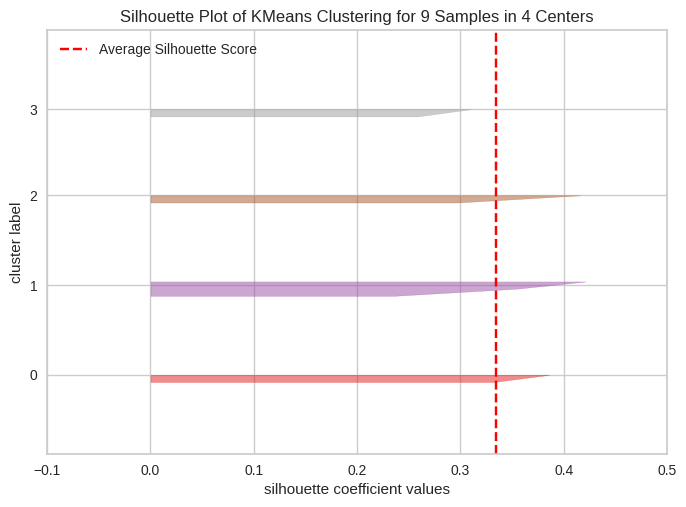

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 9 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [531]:
best_k_umap = 4
model = KMeans(n_clusters=best_k_umap, random_state=42, n_init=10)
viz = SilhouetteVisualizer(model)
viz.fit(umap_embeddings)
viz.show()

## **2. Cluster Summary**

In [532]:
best_k_umap = 4

kmeans_umap = KMeans(n_clusters=best_k_umap, random_state=42, n_init=10)
season_df["cluster_umap"] = kmeans_umap.fit_predict(umap_embeddings)

In [533]:
cluster_summary_umap = (
    season_df
    .groupby("cluster_umap")
    .agg(
        count=("season", "count"),
        seasons=("season", lambda x: sorted(list(x))))
    .reset_index())

cluster_summary_umap

,cluster_umap,count,seasons
0,0,2,"[3, 4]"
1,1,3,"[6, 7, 8]"
2,2,2,"[1, 2]"
3,3,2,"[5, 9]"


## **3. Cluster Visualisation on 3D Plane**

In [534]:
plot_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2", "UMAP3"])

plot_df["season"] = season_df["season"].astype(str)
plot_df["cluster_umap"] = season_df["cluster_umap"].astype(str)

fig = px.scatter_3d(
    plot_df,
    x="UMAP1",
    y="UMAP2",
    z="UMAP3",
    color="cluster_umap",
    text="season",
    title="KMeans Clusters on UMAP Plane")


fig.show()

# **9. PCA Vs UMAP**

## **1. Silhoutte Score**

Notably, the optimal number of clusters (k = 4, 0.33) is the same in both PCA and UMAP space, indicating consistent structural grouping across both linear and non-linear dimensionality reduction methods.

## **2. KMeans Clusters**

K-Means clustering in both PCA and UMAP spaces produces the same four clusters with the same season groupings.

This indicates that the underlying relationships between survival duration, medical risk, demography, geography, and audience response are strong enough to persist across different dimensionality reduction approaches.

# **CONCLUSION**

Yes, the seasons of Alone can be grouped into distinct types when survival outcomes, contestant characteristics, geography, and audience engagement are analyzed together.

Using season-level aggregation, dimensionality reduction (PCA and UMAP), and K-Means clustering, we find clear evidence that the seasons naturally form four distinct groups.

The clusters can be broadly characterized as:

**Cluster 0 (Seasons 3 & 4) – High Survival, Lower Latitude**

Long survival durations with moderate evacuation rates, occurring at the lowest latitude among all clusters. These seasons reflect strong competitive performance in comparatively milder environments, with steady viewership but comparatively lower IMDb ratings.

**Cluster 1 (Seasons 6, 7 & 8) – Most Extreme, High Latitude**

Longest survival times combined with the highest evacuation rates and highest latitude. These seasons are the most physically demanding and receive the strongest IMDb ratings despite lower overall viewership.

**Cluster 2 (Seasons 1 & 2) – Shorter, Lower Risk, High Engagement**

Shortest survival durations and minimal medical evacuations, yet achieving the highest viewership and rating volume. These seasons reflect lower survival intensity but strong audience attention, likely influenced by novelty.

**Cluster 3 (Seasons 5 & 9) – Moderate Survival, High Latitude**

Moderate survival duration with relatively high latitude and evacuation rates. These seasons show meaningful environmental difficulty and strong IMDb ratings, but lower rating volume, placing them between the early lower-intensity seasons and the most extreme cluster.

# **Use of Generative AI Tools**

• GenAI was used for conceptual understanding & reasoning and coding guidance.

• All outputs were reviewed, revised, modified, and validated.

• It was not used to interpret results or derive conclusions.

Link – https://chatgpt.com/share/699cf99d-c420-8005-82ae-f9f7b0155959
